In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [25]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import kagglehub

In [26]:
print("Downloading Paul Mooney's Chest X-Ray dataset...")
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print(f"Dataset downloaded to: {path}")

# Dynamically find the directory that contains 'train', 'test', and 'val'
base_dir = path
for root, dirs, files in os.walk(path):
    if all(folder in dirs for folder in ['train', 'test', 'val']):
        base_dir = root
        break

print(f"Dataset root directory located at: {base_dir}\n")

Dataset downloaded to: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia
Dataset root directory located at: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray



In [27]:
data = []
splits = ['train', 'test', 'val']
classes = ['NORMAL', 'PNEUMONIA']

for split in splits:
    for cls in classes:
        folder_path = os.path.join(base_dir, split, cls)
        if os.path.exists(folder_path):
            # Scan for all files in the directory
            for file in os.listdir(folder_path):
                # Safely capture all standard image formats
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(folder_path, file)
                    data.append({'Split': split, 'Class': cls, 'Path': img_path})

df = pd.DataFrame(data)

In [31]:
if df.empty:
    print("❌ ERROR: No images found. Please check the dataset structure.")
else:
    print("✅ Images successfully loaded!\n")
    print("--- Image Counts per Split and Class ---")
    summary_table = pd.crosstab(df['Split'], df['Class'], margins=True, margins_name="Total")
    print(summary_table)
    print("\n")

✅ Images successfully loaded!

--- Image Counts per Split and Class ---
Class  NORMAL  PNEUMONIA  Total
Split                          
test      234        390    624
train    1341       3875   5216
val         8          8     16
Total    1583       4273   5856




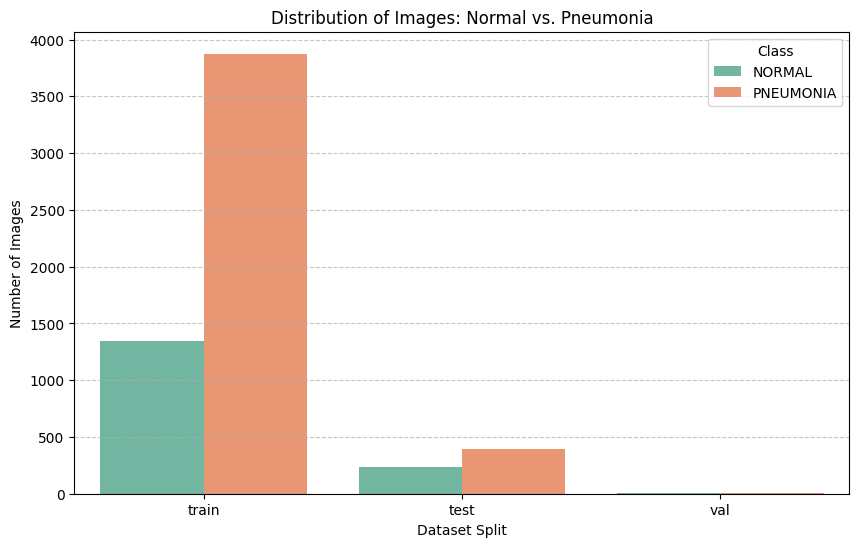

In [32]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Split', hue='Class', palette='Set2')
plt.title('Distribution of Images: Normal vs. Pneumonia')
plt.xlabel('Dataset Split')
plt.ylabel('Number of Images')
plt.legend(title='Class')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

--- Visualizing Samples ---


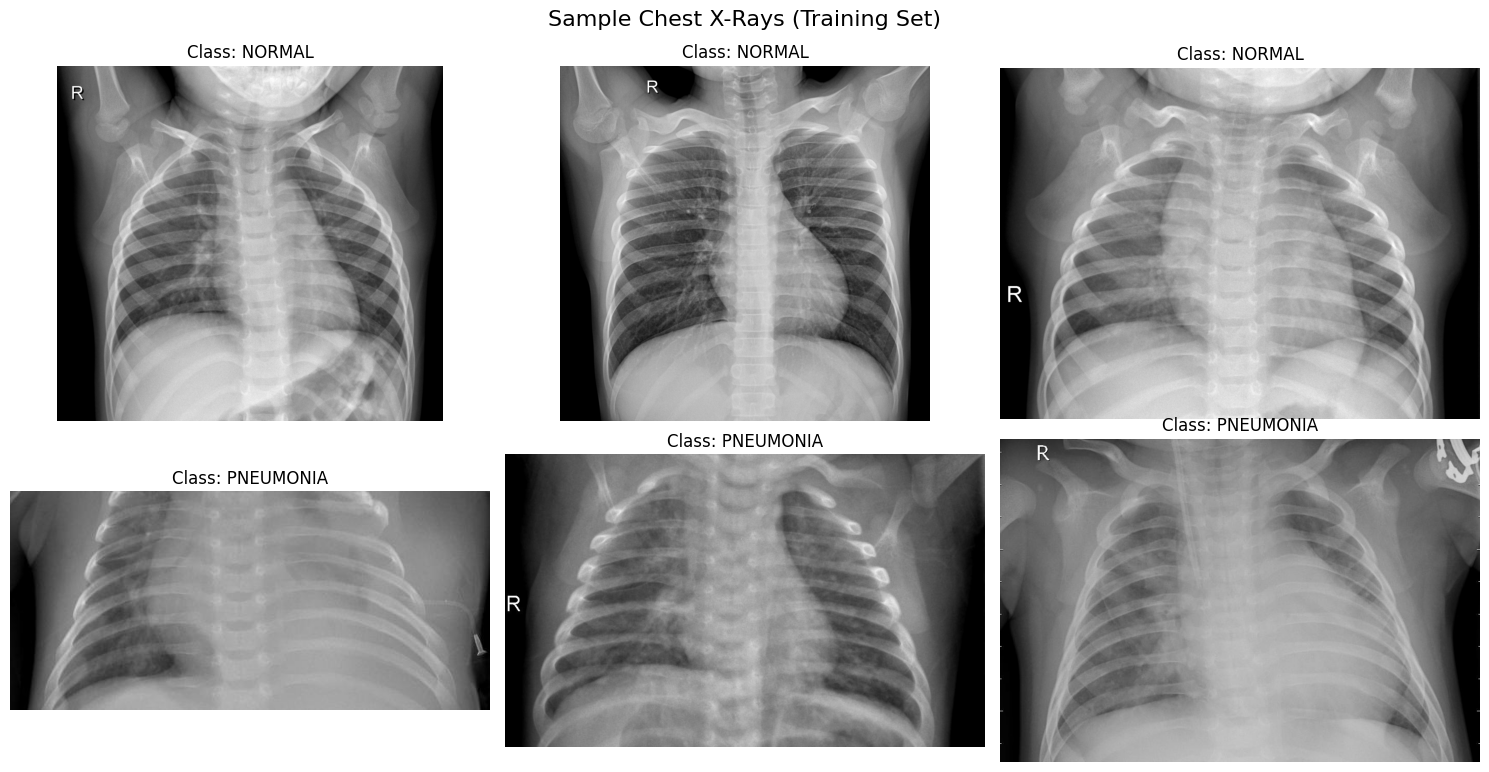

In [33]:
def show_sample_images(dataframe, num_samples=3):
    classes = ['NORMAL', 'PNEUMONIA']
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 8))
    fig.suptitle('Sample Chest X-Rays (Training Set)', fontsize=16)
    
    for i, cls in enumerate(classes):
        sample_df = dataframe[(dataframe['Split'] == 'train') & (dataframe['Class'] == cls)]
        if not sample_df.empty:
            # Get random samples
            sample_paths = sample_df['Path'].sample(min(num_samples, len(sample_df))).values
            
            for j, img_path in enumerate(sample_paths):
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert for matplotlib
                axes[i, j].imshow(img)
                axes[i, j].set_title(f"Class: {cls}")
                axes[i, j].axis('off')
                
    plt.tight_layout()
    plt.show()

print("--- Visualizing Samples ---")
show_sample_images(df)

In [38]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

E0000 00:00:1773323416.376066      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773323416.423202      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773323416.802538      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773323416.802597      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773323416.802601      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773323416.802604      55 computation_placer.cc:177] computation placer already registered. Please check linka

In [39]:
print("--- 1. Loading Data ---")
# Assuming 'path' is still defined from your kagglehub download
base_dir = path
for root, dirs, files in os.walk(path):
    if 'train' in dirs and 'test' in dirs:
        base_dir = root
        break

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'test') # Using 'test' as our validation set

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# TensorFlow's built-in directory loader handles mapping and labels automatically
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, shuffle=True, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir, shuffle=False, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)

# Optimize data loading for speed
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

--- 1. Loading Data ---
Found 5216 files belonging to 2 classes.


I0000 00:00:1773323469.036862      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13355 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


Found 624 files belonging to 2 classes.


In [40]:
print("\n--- 2. Building ResNet50 Model ---")
# Load pre-trained ResNet50 without its original classification head
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model to train only our new classification head (Transfer Learning)
base_model.trainable = False 

# Build our custom model on top
inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.resnet50.preprocess_input(inputs) # ResNet specific preprocessing
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x) # Prevent overfitting
outputs = layers.Dense(1, activation='sigmoid')(x) # 1 neuron for binary (Normal vs Pneumonia)

model = models.Model(inputs, outputs)

# Compile with Adam
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print Parameters
model.summary()


--- 2. Building ResNet50 Model ---
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [41]:
class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.total_time_start = time.time()

    def on_epoch_begin(self, epoch, logs={}):
        self.epoch_time_start = time.time()

    def on_epoch_end(self, epoch, logs={}):
        epoch_time = time.time() - self.epoch_time_start
        print(f" -> Epoch {epoch + 1} Time: {epoch_time:.2f} seconds")

    def on_train_end(self, logs={}):
        total_time = time.time() - self.total_time_start
        print(f"\nTotal Training Time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")

time_callback = TimeHistory()

In [42]:
print("\n--- 3. Starting Training ---")
EPOCHS = 10 # Start with 10 for transfer learning

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[time_callback],
    verbose=1 # Prints standard progress bar
)

# Calculate physical model size
model.save('/kaggle/working/resnet50_pneumonia.h5')
size_mb = os.path.getsize('/kaggle/working/resnet50_pneumonia.h5') / (1024 * 1024)
print(f"\nModel Saved. Physical Size on Disk: {size_mb:.2f} MB")


--- 3. Starting Training ---
Epoch 1/10


I0000 00:00:1773323537.234972     381 service.cc:152] XLA service 0x7941fc0121d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773323537.235011     381 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773323539.456206     381 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/163 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.3125 - loss: 1.9722 

I0000 00:00:1773323543.961472     381 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.7762 - loss: 0.5474 -> Epoch 1 Time: 42.51 seconds
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 177ms/step - accuracy: 0.7769 - loss: 0.5458 - val_accuracy: 0.7516 - val_loss: 0.5645
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9490 - loss: 0.1369 -> Epoch 2 Time: 15.07 seconds
163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.9491 - loss: 0.1367 - val_accuracy: 0.7772 - val_loss: 0.5607
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9593 - loss: 0.1016 -> Epoch 3 Time: 15.27 seconds
163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.9594 - loss: 0.1016 - val_accuracy: 0.7885 - val_loss: 0.5476
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9655 - loss: 0.0886 -> Epoch 4 Time: 14.86 seconds
163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 91ms/step - accuracy: 0.9656 - loss: 0.0886 - val_accuracy: 0.7949 - val_loss: 0.5546
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accura


Total Training Time: 176.81 seconds (2.95 minutes)

Model Saved. Physical Size on Disk: 90.38 MB



--- 4. Generating Plots ---


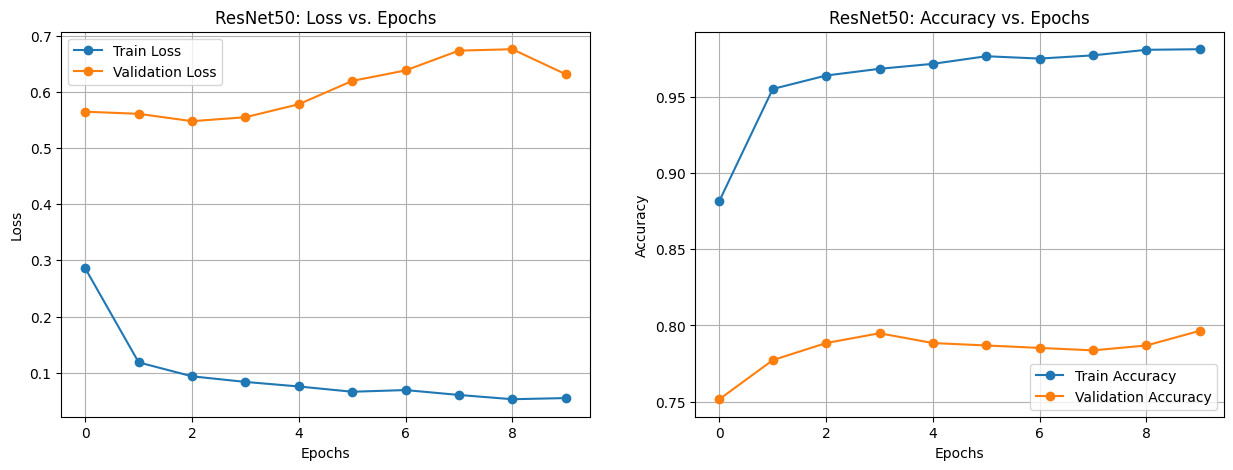

In [43]:
print("\n--- 4. Generating Plots ---")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', marker='o')
axes[0].plot(history.history['val_loss'], label='Validation Loss', marker='o')
axes[0].set_title('ResNet50: Loss vs. Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
axes[1].set_title('ResNet50: Accuracy vs. Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.show()


--- 5. Detailed Evaluation ---
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step
Accuracy:  0.7965
Precision: 0.7563
Recall:    0.9949
F1 Score:  0.8594


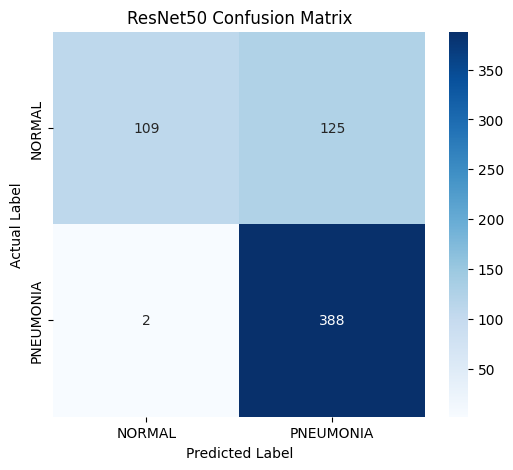

In [45]:
print("\n--- 5. Detailed Evaluation ---")
# Extract actual labels from validation dataset
y_true = np.concatenate([y for x, y in val_ds], axis=0)

# Get raw predictions and convert to binary classes (0 or 1)
y_pred_probs = model.predict(val_ds)
y_pred = (y_pred_probs > 0.5).astype(int)

# Calculate Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))

# FIX: Manually providing the class names here
class_labels = ['NORMAL', 'PNEUMONIA']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, 
            yticklabels=class_labels)

plt.title('ResNet50 Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

--- 1. Scanning Images ---

--- BEFORE OVERSAMPLING (Training Set) ---
Class
PNEUMONIA    3875
NORMAL       1341
Name: count, dtype: int64

--- 2. Applying Oversampling ---

--- AFTER OVERSAMPLING (Training Set) ---
Class
PNEUMONIA    3875
NORMAL       3875
Name: count, dtype: int64


/tmp/ipykernel_55/2530633041.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df_balanced, x='Class', palette='Set2')


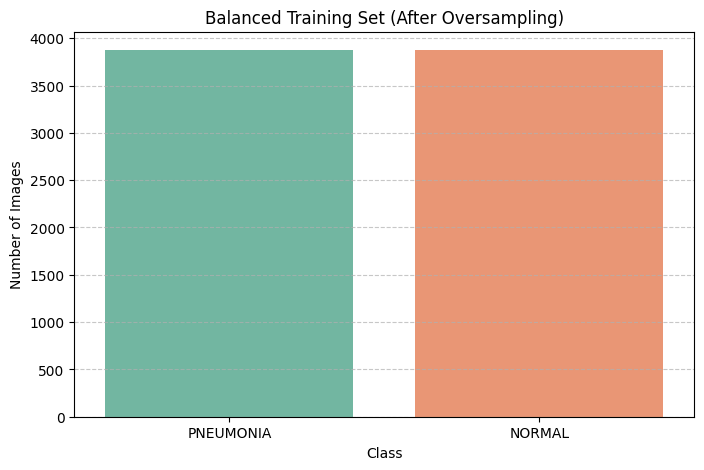

In [46]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample

# ==========================================
# 1. BUILD THE INITIAL DATAFRAME
# ==========================================
print("--- 1. Scanning Images ---")
data = []
# Assuming base_dir is already located from your previous download step
for split in ['train', 'test']:  # We use 'test' as our validation set
    for cls in ['NORMAL', 'PNEUMONIA']:
        folder = os.path.join(base_dir, split, cls)
        if os.path.exists(folder):
            for file in os.listdir(folder):
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    data.append({'Split': split, 'Class': cls, 'Path': os.path.join(folder, file)})

df = pd.DataFrame(data)

# Separate the data into Training and Validation DataFrames
train_df = df[df['Split'] == 'train'].copy()
val_df = df[df['Split'] == 'test'].copy()

print("\n--- BEFORE OVERSAMPLING (Training Set) ---")
print(train_df['Class'].value_counts())

# ==========================================
# 2. PERFORM OVERSAMPLING ON THE MINORITY CLASS
# ==========================================
print("\n--- 2. Applying Oversampling ---")
# Separate the majority and minority classes
majority_class = train_df[train_df['Class'] == 'PNEUMONIA']
minority_class = train_df[train_df['Class'] == 'NORMAL']

# Upsample the minority class (NORMAL) to match the majority class
minority_upsampled = resample(
    minority_class, 
    replace=True,                     # Sample with replacement (allows duplication of paths)
    n_samples=len(majority_class),    # Match the exact count of the majority class
    random_state=42                   # Keeps the randomization reproducible
)

# Combine the majority class with the newly upsampled minority class
# .sample(frac=1) shuffles the rows so the model doesn't see all 'Normal' images in a row
train_df_balanced = pd.concat([majority_class, minority_upsampled]).sample(frac=1, random_state=42).reset_index(drop=True)

print("\n--- AFTER OVERSAMPLING (Training Set) ---")
print(train_df_balanced['Class'].value_counts())

# ==========================================
# 3. VISUALIZE THE BALANCED DATA
# ==========================================
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df_balanced, x='Class', palette='Set2')
plt.title('Balanced Training Set (After Oversampling)')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [47]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [48]:
print("--- 1. Setting up Data Generators ---")

# Training Generator with Data Augmentation
# We add slight rotations/shifts so the duplicated 'Normal' images look slightly different each time
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # ResNet50 requires specific pixel scaling
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Validation Generator (NO augmentation, just preprocessing)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Flow from DataFrames
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df_balanced, # Your balanced dataframe from the EDA step!
    x_col='Path',
    y_col='Class',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='Path',
    y_col='Class',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False # MUST be False for accurate evaluation/confusion matrix later!
)

# ==========================================
# 2. BUILD THE RESNET50 MODEL
# ==========================================
print("\n--- 2. Building ResNet50 Model ---")
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Transfer Learning

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x) # Slightly higher dropout to prevent overfitting
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

--- 1. Setting up Data Generators ---
Found 7750 validated image filenames belonging to 2 classes.
Found 624 validated image filenames belonging to 2 classes.

--- 2. Building ResNet50 Model ---


In [49]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [50]:
class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.total_time_start = time.time()
    def on_epoch_begin(self, epoch, logs={}):
        self.epoch_time_start = time.time()
    def on_epoch_end(self, epoch, logs={}):
        print(f" -> Epoch {epoch + 1} Time: {time.time() - self.epoch_time_start:.2f} seconds")
    def on_train_end(self, logs={}):
        total_time = time.time() - self.total_time_start
        print(f"\nTotal Training Time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")

# Early Stopping: Stops if validation loss doesn't improve for 5 epochs
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True, 
    verbose=1
)

In [51]:
print("\n--- 3. Starting Training ---")
MAX_EPOCHS = 30 # A good maximum amount. Early stopping will likely halt it before 30.

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=MAX_EPOCHS,
    callbacks=[TimeHistory(), early_stop],
    verbose=1
)

# Calculate model size
model.save('/kaggle/working/resnet50_balanced.h5')
size_mb = os.path.getsize('/kaggle/working/resnet50_balanced.h5') / (1024 * 1024)
print(f"\nModel Saved. Physical Size on Disk: {size_mb:.2f} MB")


--- 3. Starting Training ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 749ms/step - accuracy: 0.8646 - loss: 0.3060 -> Epoch 1 Time: 205.93 seconds
243/243 ━━━━━━━━━━━━━━━━━━━━ 206s 805ms/step - accuracy: 0.8648 - loss: 0.3057 - val_accuracy: 0.8958 - val_loss: 0.2593
Epoch 2/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 727ms/step - accuracy: 0.9455 - loss: 0.1467 -> Epoch 2 Time: 182.53 seconds
243/243 ━━━━━━━━━━━━━━━━━━━━ 183s 751ms/step - accuracy: 0.9455 - loss: 0.1467 - val_accuracy: 0.8958 - val_loss: 0.2563
Epoch 3/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 747ms/step - accuracy: 0.9615 - loss: 0.1108 -> Epoch 3 Time: 187.97 seconds
243/243 ━━━━━━━━━━━━━━━━━━━━ 188s 773ms/step - accuracy: 0.9615 - loss: 0.1108 - val_accuracy: 0.8830 - val_loss: 0.2666
Epoch 4/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 736ms/step - accuracy: 0.9638 - loss: 0.1073 -> Epoch 4 Time: 185.37 seconds
243/243 ━━━━━━━━━━━━━━━━━━━━ 186s 763ms/step - accuracy: 0.9638 - loss: 0.1073 - val_accuracy: 0.8990 - val_loss: 0.2392
Epoch 5/30
243/243 ━━━━━━━━━━━━━━━━━


Model Saved. Physical Size on Disk: 90.38 MB



--- 4. Generating Plots ---


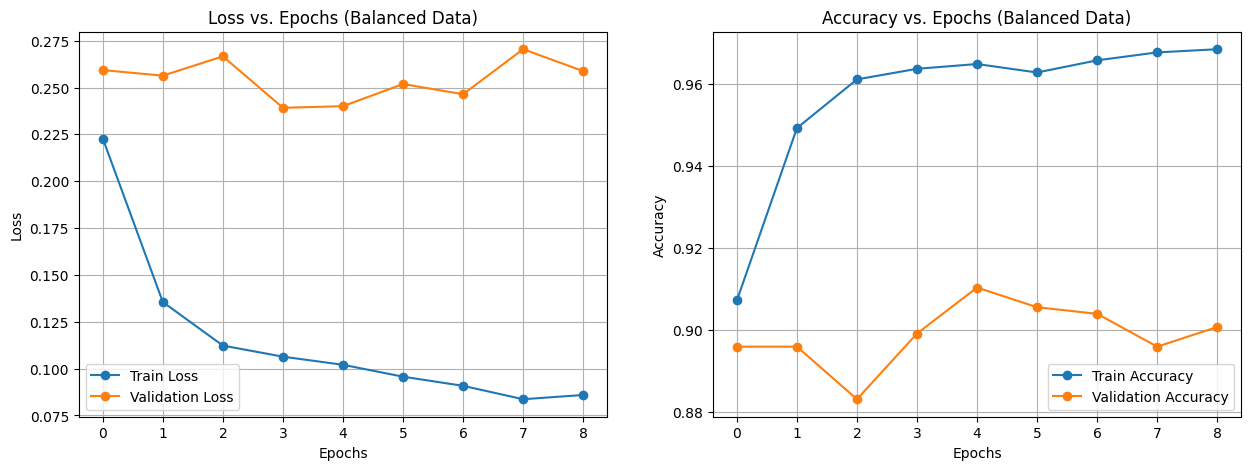

In [52]:
print("\n--- 4. Generating Plots ---")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['loss'], label='Train Loss', marker='o')
axes[0].plot(history.history['val_loss'], label='Validation Loss', marker='o')
axes[0].set_title('Loss vs. Epochs (Balanced Data)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
axes[1].set_title('Accuracy vs. Epochs (Balanced Data)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.show()


--- 5. Detailed Evaluation ---
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 515ms/step
Accuracy:  0.8990
Precision: 0.9077
Recall:    0.9333
F1 Score:  0.9204


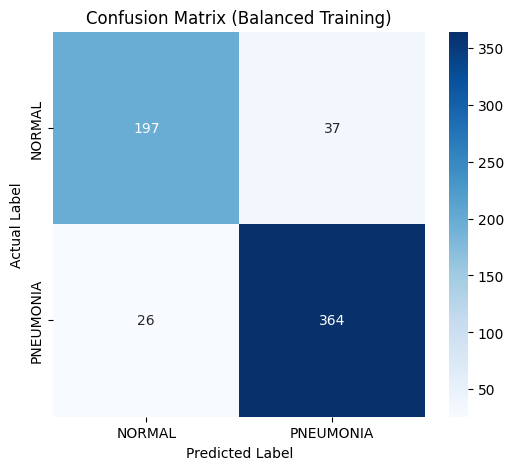

In [53]:
print("\n--- 5. Detailed Evaluation ---")
# Get actual labels directly from the generator
y_true = val_generator.classes 

# Get predictions
y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Calculate Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))

# The generator dynamically maps class names to indices. Let's fetch them to be completely accurate.
class_labels = list(val_generator.class_indices.keys())

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, 
            yticklabels=class_labels)

plt.title('Confusion Matrix (Balanced Training)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()